# Single Color Correction Validation
Goal: recreating plots in Figure 7 of DMTN 266 with DP1 data
https://dmtn-266.lsst.io/DMTN-266.pdf

Author: Maya Redden, msredden@stanford.edu

In [9]:
#import general packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler


from astropy.table import vstack
from astropy.table import Table, join
import astropy.units as u
from scipy.optimize import curve_fit


#import LSST packages
from lsst.rsp import get_tap_service
import lsst.daf.butler as dafButler
from lsst.geom import LinearTransform, radians
from lsst.afw.geom import Quadrupole, Ellipse

from utils import apply_filter, rebin

field_centers = {
    "47 Tuc": [6.02, -72.08],
    "SV 38 7": [37.86, 6.98],
    "Fornax": [40.00, -34.45],
    "ECDFS": [53.13, -28.10],
    "EDFS": [59.10, -48.73],
    "SV 95 -25": [95.00, -25.00],
    "Seagull": [106.23, -10.51],
}

In [10]:
# Run a wide object search around the ECDFS

# query_simple looks for stars (refExtendedness = 0.0) in the ECDFS

query_simple = """ SELECT TOP 100 coord_dec,
            coord_ra,
            g_cModelMag,
            r_cModelMag,
            i_cModelMag,
            u_cModelMag,
            z_cModelMag,
            shape_xx,
            shape_xy,
            shape_yy,
            refExtendedness,
            g_calib_psf_reserved,
            g_calib_psf_used,
            g_cModelMag - r_cModelMag as grColor,
            g_cModelMag - i_cModelMag as giColor,
            r_cModelMag - z_cModelMag as rzColor,
            u_cModelMag - g_cModelMag as ugColor
    FROM dp1.Object 
    WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', 53.13, -28.10, 3600/3600))=1
            AND (g_cModelMag < 23 AND g_cModelMag > 18)
            AND refExtendedness = 0
            """

# Other constraints to consider:
# AND g_calib_psf_used = 0
# AND (g_cModelMag < 23 AND g_cModelMag > 18)
# AND refExtendedness = 0.0
# AND (r_cModelMag - g_cModelMag) > 0


service = get_tap_service("tap")
job = service.submit_job(query_simple)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
object_table = job.fetch_result().to_table()

print(len(object_table))

Job phase is COMPLETED
100


(array([ 3., 14.,  6.,  3.,  3.,  8., 10., 18.,  7.,  5.]),
 array([0.05123711, 0.36605186, 0.68086662, 0.99568138, 1.31049614,
        1.6253109 , 1.94012566, 2.25494041, 2.56975517, 2.88456993,
        3.19938469]),
 <BarContainer object of 10 artists>)

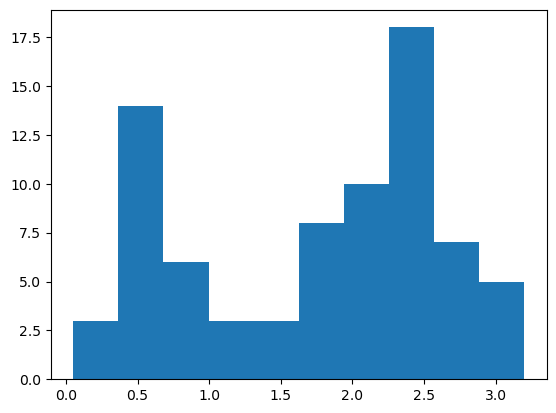

In [52]:
plt.hist(object_table['giColor'])

In [14]:
# This is a complicated source query that returns the source detections for each star in the defined color bins
# Avoid doing this more than once (takes a really long time) 
def source_query(coords):
    search_radius = 2 #arcsec
    search_circles = [f"CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1" for ra, dec in np.array([coords['coord_ra'], coords['coord_dec']]).T]
    search_string = " OR ".join(map(str, search_circles))
    
    source_query = f"""SELECT band,
                coord_dec,
                coord_ra,
                dec,
                decErr,
                detector,
                ra,
                raErr,
                visit,
                psfFlux,
                psfFluxErr
                
        FROM dp1.Source 
        WHERE (band = 'g' OR band = 'i' or band = 'u' or band = 'r' or band = 'z') AND ({search_string})
        AND psfFluxErr / psfFlux < 0.01
        """
    
    
    job = service.submit_job(source_query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    print('Job phase is', job.phase)
    if job.phase == 'ERROR':
        job.raise_if_error()
    assert job.phase == 'COMPLETED'
    source_table = job.fetch_result().to_table()
    return source_table


source_table = source_query(object_table['coord_ra', 'coord_dec'])


print(len(source_table))
print('u band sources returned', np.sum(source_table['band'] == 'u'))
print('g band sources returned', np.sum(source_table['band'] == 'g'))
print('r band sources returned', np.sum(source_table['band'] == 'r'))
print('i band sources returned', np.sum(source_table['band'] == 'i'))
print('z band sources returned', np.sum(source_table['band'] == 'z'))


Job phase is COMPLETED
680
u band sources returned 1
g band sources returned 187
r band sources returned 257
i band sources returned 135
z band sources returned 100


In [23]:
#visit table
visit_IDs = source_table['visit']

unique_visits = np.unique(visit_IDs)

visit_string = "','".join(map(str, unique_visits))

visit_query = f"""SELECT airmass,
                        altitude,
                        azimuth,
                        band as band_visit,
                        dec as dec_visit,
                        expTime,
                        ra as ra_visit,
                        skyRotation,
                        visit,
                        zenithDistance,
                        expMidptMJD 
    FROM dp1.Visit 
    WHERE visit IN ('{visit_string}')"""


job = service.submit_job(visit_query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
visit_table = job.fetch_result().to_table()

print(len(visit_table))

Job phase is COMPLETED
170


In [38]:
#join source and visit tables into a master table
master = join(source_table, visit_table, keys = 'visit')

In [39]:
# Add color columns from object_table to master by coordinate matching.
# Uses search_around_sky for a fully vectorized cross-match (no iteration over master).
# Master rows within 2" of more than one object_table entry get NaN colors.

from astropy.coordinates import SkyCoord, search_around_sky

master_coords = SkyCoord(ra=np.array(master['ra']) * u.deg, dec=np.array(master['dec']) * u.deg)
object_coords = SkyCoord(ra=np.array(object_table['coord_ra']) * u.deg, dec=np.array(object_table['coord_dec']) * u.deg)

# All (master, object) pairs within 2 arcsec
idx_master, idx_obj, sep2d, _ = search_around_sky(master_coords, object_coords, 2 * u.arcsec)

# Find which master indices appear more than once (ambiguous matches)
unique_master_ids, counts = np.unique(idx_master, return_counts=True)
single_match_ids = unique_master_ids[counts == 1]

# Keep only pairs where the master row has exactly one match
keep = np.isin(idx_master, single_match_ids)
idx_master_unique = idx_master[keep]
idx_obj_unique = idx_obj[keep]

# Add color columns to master, NaN by default
color_cols = ['grColor', 'giColor', 'rzColor', 'ugColor', 'coord_ra', 'coord_dec']
for col in color_cols:
    col_data = np.full(len(master), np.nan)
    col_data[idx_master_unique] = np.array(object_table[col])[idx_obj_unique]
    master[col +"_obj"] = col_data

print(f"Total master rows:        {len(master)}")
print(f"Uniquely matched:         {len(idx_master_unique)}")
print(f"Ambiguous (NaN colors):   {int(np.sum(counts > 1))}")
print(f"Unmatched (no object):    {len(master) - len(unique_master_ids)}")

Total master rows:        680
Uniquely matched:         680
Ambiguous (NaN colors):   0
Unmatched (no object):    0


In [40]:

from astropy.time import Time
from astropy.coordinates import EarthLocation, Angle, AltAz, SkyCoord
def add_parallactic_angle(table, ra_col = 'ra', dec_col = 'dec', expMidptMJD_col = 'expMidptMJD', lat = -30.244633,lon = -70.749417, height = 2647):
    # Calculate the parallactic angle and add to the table
    
    loc = EarthLocation(lat = lat * u.deg, lon = lon * u.deg, height = height * u.m)
    
    times = Time(table[expMidptMJD_col], format = 'mjd', scale = 'utc')
    lst = times.sidereal_time(kind = 'mean', longitude = loc.lon)
    HA = (lst - Angle(list(table[ra_col])* u.deg)).wrap_at(180*u.deg)
    
    H_rad = HA.to(u.rad).value
    phi = Angle(lat * u.deg).to(u.rad).value #lat * np.pi/180
    delta = Angle(np.array(table[dec_col])*u.deg).to(u.rad).value #np.array(master['dec_1']) * np.pi/180
    
    numerator = np.sin(H_rad)
    denominator = np.tan(phi) * np.cos(delta) - np.sin(delta) * np.cos(H_rad)
    
    q_rad = np.arctan2(numerator, denominator)   # result in radians
    q = q_rad * u.rad
    
    # normalize to (-180,180] or whatever you prefer — here we return angle wrapped to [-180,180)
    q = Angle(q).wrap_at(360*u.deg)

    table['q'] = q.value

    return table
    
master = add_parallactic_angle(master)

print(master['q'][0:10])

        q         
------------------
1.8041148460436198
1.8034411183569627
1.7990195315860815
 1.798861655794811
1.7990794418493616
1.7991855778358845
1.7641537591153018
1.8016035461613766
1.8020636927707785
1.8024381600500938


In [46]:
def compute_dR_and_err(center_ra, center_dec, ra, dec, par, raErr, decErr, ra_dec_Cov):
        # For a trial center, compute projected zenith offset dR and propagated uncertainty dR_err.
        dR = np.zeros(len(ra))
        dR_err = np.zeros(len(ra))

        for i in range(len(ra)):
            # Rotation from RA/Dec offsets into azimuth/altitude frame using parallactic angle q.
            cq, sq = np.cos(par[i]), np.sin(par[i])
            rot = np.array([[cq, -sq], [sq, cq]])

            dRA = (ra[i] - center_ra[i]) * np.cos(dec[i] * np.pi / 180)
            dDec = dec[i] - center_dec[i]
            _, dalt = rot @ np.array([[dRA, dDec]]).T
            dR[i] = dalt

            # Propagate RA/Dec covariance into rotated frame and keep altitude component uncertainty.
            cov_matrix = np.array([[raErr[i]**2, ra_dec_Cov[i]],
                                   [ra_dec_Cov[i], decErr[i]**2]])
            r_err_matrix = rot @ cov_matrix @ rot.T
            dR_err[i] = np.sqrt(np.abs(r_err_matrix[1, 1]))

        # Keep only finite, positive uncertainties for weighted residuals.
        finite_mask = np.isfinite(dR) & np.isfinite(dR_err) & (dR_err > 0)
        return dR, dR_err, finite_mask


par = np.array(master['q'])
center_ra = np.array(master['coord_ra_obj'])
center_dec = np.array(master['coord_dec_obj'])
ra = np.array(master['ra'])
dec = np.array(master['dec'])
raErr = np.array(master['raErr'])
decErr = np.array(master['decErr'])
ra_dec_Cov = np.array(master['raErr'])*0.001

dR, dR_err, finite_mask = compute_dR_and_err(center_ra, center_dec, ra, dec, par, raErr, decErr, ra_dec_Cov)
master['dR'] = dR
master['dR_err'] = dR_err

/tmp/ipykernel_3509/1978009203.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dR[i] = dalt


In [41]:
master['ra','coord_ra_obj', 'giColor_obj', 'q', 'airmass'][0:10]

ra,coord_ra_obj,giColor_obj,q,airmass
deg,,,,
float64,float64,float64,float64,float64
52.7255343391289,52.72553314091862,2.0256881713867188,1.8041148460436198,1.05287302501876
52.725536099532874,52.72553314091862,2.0256881713867188,1.8034411183569627,1.0544557351707
53.12506920269204,53.12507007884748,2.2787094116210938,1.7990195315860815,1.08835850688522
52.96598784150936,52.96598521431063,0.7329730987548828,1.798861655794811,1.08835850688522
53.12506918106583,53.12507007884748,2.2787094116210938,1.7990794418493616,1.09047725095909
53.12506882724256,53.12507007884748,2.2787094116210938,1.7991855778358845,1.09302024428042
53.53705308392909,53.537055459564186,2.4698448181152344,1.7641537591153018,1.11495130884417
52.849464625064314,52.8494677129615,0.5839309692382812,1.8016035461613766,1.11820164768953


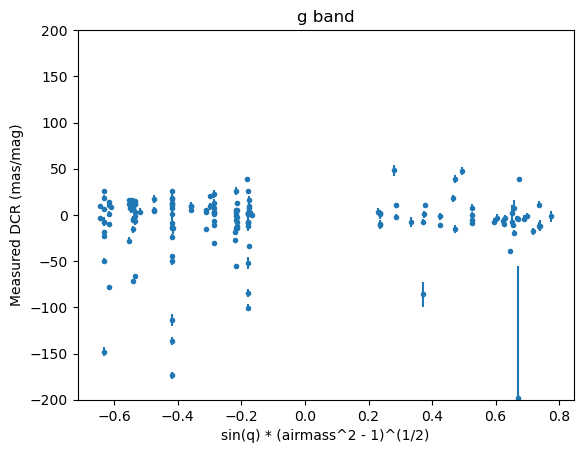

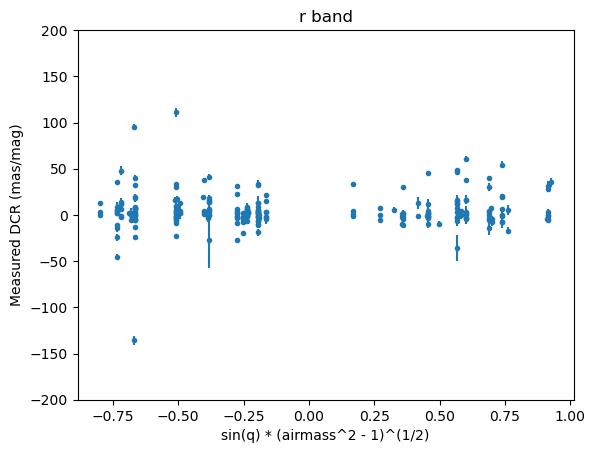

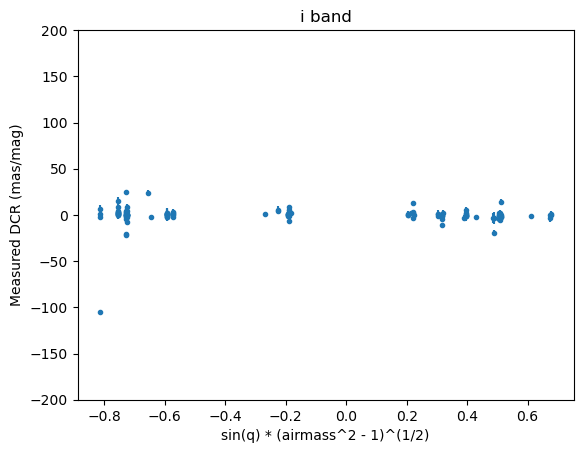

In [59]:

for band in 'gri':
    band_mask = master['band'] == band
    
    airmass = master[band_mask]['airmass']
    delta_RA = (master[band_mask]['ra'] - master[band_mask]['coord_ra_obj']) * 3600 * 1000
    RA_err = master[band_mask]['raErr'] * 3600 * 1000
    dR = master[band_mask]['dR'] * 3600 * 1000
    dRerr = master[band_mask]['dR_err'] * 3600 * 1000
    color = master[band_mask]['giColor_obj']
    q = master[band_mask]['q']
    
    z = np.arccos(1 / airmass) * 180 / np.pi
    
    y = delta_RA/color
    # x = (airmass**2 - 1)**(1/2)
    x = np.sin(q) * np.tan(z  * np.pi/180)

    plt.errorbar(x, y, fmt = '.', yerr = RA_err)
    
    plt.ylim(-200, 200)
    # plt.xlim(0, 46)
    
    plt.title(f'{band} band')
    plt.xlabel('sin(q) * (airmass^2 - 1)^(1/2)')
    plt.ylabel('Measured DCR (mas/mag)')
    # plt.legend()
    

    plt.show()
    plt.close()